# ISH and CAM-chem-se with UXARRAY directly

First we need to import the driver.

In [1]:
from melodies_monet import driver

In [2]:
# Needed if you want to make changes to `melodies_monet` and don't want to restart kernel:
%load_ext autoreload

%autoreload 2

## Initiate the analysis class

Now lets create an instance of the {mod}`melodies_monet.driver` {class}`~melodies_monet.driver.analysis` class.
It consists of 4 main parts: model instances, observation instances, a paired instance of both.
This will allow us to move things around the plotting function for spatial and overlays and more complex plots.

In [3]:
an = driver.analysis()
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control File

Read in the required yaml control file that sets up all the definitions of what we want to pair and plot.

In [4]:
an.control = '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/readthedocs/control_ish_cesm-se_20240101.yaml'
an.read_control()
an.control_dict

{'analysis': {'start_time': '2024-01-01',
  'end_time': '2024-01-03',
  'output_dir': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/readthedocs/output/ish_cesmse',
  'output_dir_save': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/readthedocs/output/ish_cesmse',
  'output_dir_read': '/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/readthedocs/output/ish_cesmse',
  'save': {'paired': {'method': 'netcdf',
    'prefix': '20240101',
    'data': 'all'}},
  'read': {'paired': {'method': 'netcdf',
    'filenames': {'ish_cesm_se': ['ish_cesm_se']}}},
  'download_maps': False,
  'debug': False},
 'model': {'cam-chem-se': {'files': ['/glade/campaign/acom/acom-da/conus_outputs/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002/H1/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.

## Load the model data 

The driver will automatically loop through the "models" found in the model section of the control file and create model classes for each. Classes include the label, mapping information, and xarray object as well as the filenames.  Note it can open multiple files easily by including wildcards. Here we are only opening one CAM-chem file.

In [5]:
an.open_models()

Scrip file /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc
cesm_se
['/glade/campaign/acom/acom-da/conus_outputs/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002/H1/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002.cam.h1.2024-01-01-03600.nc', '/glade/campaign/acom/acom-da/conus_outputs/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002/H1/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002.cam.h1.2024-01-02-03600.nc']
**** Reading CAM unstructured model output (cesm_se / mpas)...
Using unstructured grid file: /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc
Opening unstructured grid with UXArray: /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc


/glade/work/lcthompson/conda-envs/melodies-monet/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/glade/work/lcthompson/conda-envs/melodies-monet/lib/python3.11/site-packages/uxarray/core/api.py:505: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(paths, chunks=corrected_chunks, **kwargs)


unstructured reader: requested vars not in '/glade/campaign/acom/acom-da/conus_outputs/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002/H1/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002.cam.h1.2024-01-01-03600.nc': ['P0']. Continuing with: ['U', 'V', 'PS', 'Q', 'T', 'lat', 'lon', 'lev', 'hyam', 'hybm', 'PDELDRY', 'PMID'].
**** Opened uxarray grid: /glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc
Performing extra model calculations...
Calculating modeled Dewpoint...
Calculating modeled relative humidity...
Calculating modeled windspeed...
Calculating modeled wind direction...


In [6]:
an.models

{'cam-chem-se': model(
     model='cesm_se',
     is_global=False,
     radius_of_influence=27794,
     mod_kwargs={'var_list': ['U', 'V', 'PS', 'Q', 'T', 'lat', 'lon', 'lev', 'hyam', 'hybm', 'P0', 'PDELDRY', 'PMID'], 'scrip_file': '/glade/campaign/acom/MUSICA/grids/ne0CONUSne30x8/ne0CONUS_ne30x8_np4_SCRIP.nc'},
     file_str=['/glade/campaign/acom/acom-da/conus_outputs/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002/H1/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002.cam.h1.2024-01-01-03600.nc', '/glade/campaign/acom/acom-da/conus_outputs/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002/H1/f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_mt12.ERA5_ref_dust_M1.1.002.cam.h1.2024-01-02-03600.nc'],
     label='cam-chem-se',
     obj=...,
     extra_calc={'windspeed': {'u_comp': 'U', 'v_comp': 'V'}, 'winddir': {'u_comp': 'U', 'v_comp': 'V'}, 'wind_barb': {'u_comp': 'U', 'v_comp': 'V'}, 'rose_plot': {'model_wdir': 'winddir

In [7]:
an.models['cam-chem-se'].obj

<xarray.UxDataset> Size: 12GB
Dimensions:        (z: 32, time: 48, n_face: 174098)
Coordinates:
  * z              (z) float64 256B 992.6 976.3 957.5 ... 14.36 7.595 3.643
  * time           (time) datetime64[ns] 384B 2024-01-01T01:00:00 ... 2024-01-03
    latitude       (n_face) float64 1MB dask.array<chunksize=(174098,), meta=np.ndarray>
    longitude      (n_face) float64 1MB dask.array<chunksize=(174098,), meta=np.ndarray>
Dimensions without coordinates: n_face
Data variables:
    U              (time, z, n_face) float32 1GB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
    V              (time, z, n_face) float32 1GB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
    PS             (time, n_face) float32 33MB dask.array<chunksize=(24, 174098), meta=np.ndarray>
    Q              (time, z, n_face) float32 1GB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
    T              (time, z, n_face) float32 1GB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
    pres_pa_mid    (time, z, n_face) float32 1GB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
    temperature_k  (time, z, n_face) float32 1GB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
    dz_m           (time, z, n_face) float32 1GB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
    dewpoint       (time, z, n_face) float32 1GB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
    rel_hum        (time, n_face, z) float32 1GB dask.array<chunksize=(24, 174098, 32), meta=np.ndarray>
    windspeed      (time, z, n_face) float32 1GB dask.array<chunksize=(24, 32, 174098), meta=np.ndarray>
    winddir        (time, z, n_face) float32 1GB 65.12 56.85 ... 273.3 272.9
Attributes: (12/13)
    ne:                         0
    np:                         4
    Conventions:                CF-1.0
    source:                     CAM
    case:                       f.e22.FCnudged.ne0CONUSne30x8_ne0CONUSne30x8_...
    logname:                    gaubert
    ...                         ...
    initial_file:               /glade/campaign/cesm/cesmdata/inputdata/atm/c...
    topography_file:            /glade/campaign/cesm/cesmdata/inputdata/atm/c...
    model_doi_url:              https://doi.org/10.5065/D67H1H0V
    time_period_freq:           hour_1
    mio_has_unstructured_grid:  True
    mio_scrip_file:             /glade/campaign/acom/MUSICA/grids/ne0CONUSne3...

In [8]:
# All the info in the model class can be called here.
print(an.models['cam-chem-se'].label)
print(an.models['cam-chem-se'].mapping)

cam-chem-se
{'ish': {'T': 't', 'dewpoint': 'dpt', 'windspeed': 'ws', 'winddir': 'wdir'}}


In [9]:
# All the info in the analysis class can also be called.
print(an.start_time)
print(an.end_time)
print(an.download_maps)

2024-01-01 00:00:00
2024-01-03 00:00:00
True


## Open Obs

Now for monet-analysis we will open preprocessed data in either netcdf icartt or some other format.  We will not be retrieving data like monetio does for some observations (ie aeronet, airnow, etc....).  Instead we will provide utitilies to do this so that users can add more data easily.

Like models we list all obs objects in the yaml file and it will loop through and create driver.observation instances that include the model type, file, objects (i.e. data object) and label  

In [10]:
an.control_dict['obs']

{'ish': {'filename': './output/ish_cesmse/ISH_20240101_20240102.nc',
  'obs_type': 'pt_sfc',
  'variables': {'t': {'unit_scale': 273.15,
    'unit_scale_method': '+',
    'nan_value': -1.0,
    'ylabel_plot': 'Temperature 2m (K)',
    'xlabel_plot': 'Temperature 2m (K)',
    'vmin_plot': 260,
    'vmax_plot': 300,
    'vdiff_plot': 20.0,
    'nlevels_plot': 21},
   'ws': {'unit_scale': 1,
    'unit_scale_method': '*',
    'nan_value': -1.0,
    'ylabel_plot': 'Windspeed 10m (m/s)',
    'xlabel_plot': 'Windspeed 10m (m/s)',
    'vmin_plot': 0,
    'vmax_plot': 12,
    'vdiff_plot': 4,
    'nlevels_plot': 18},
   'wdir': {'unit_scale': 1,
    'unit_scale_method': '*',
    'nan_value': -1.0,
    'ylabel_plot': 'Wind Direction 10m (deg)',
    'xlabel_plot': 'Wind Direction 10m (deg)',
    'vmin_plot': 0,
    'vmax_plot': 370,
    'vdiff_plot': 4,
    'nlevels_plot': 18},
   'dpt': {'unit_scale': 273.15,
    'unit_scale_method': '+',
    'nan_value': -1.0,
    'ylabel_plot': 'Dewpoint 2m (K

In [11]:
an.open_obs()

Performing extra calculations for obs...


In [12]:
# All the info in the observation class can also be called.
an.obs['ish'].obj

<xarray.Dataset> Size: 26MB
Dimensions:       (time: 25, y: 1, x: 11895)
Coordinates:
  * time          (time) datetime64[ns] 200B 2024-01-01 ... 2024-01-02
  * x             (x) int64 95kB 0 1 2 3 4 5 ... 11890 11891 11892 11893 11894
    latitude      (x) float64 95kB ...
    longitude     (x) float64 95kB ...
    siteid        (x) <U11 523kB ...
Dimensions without coordinates: y
Data variables: (12/19)
    varlength     (time, y, x) float64 2MB ...
    wdir          (time, y, x) float64 2MB 318.0 nan nan 150.0 ... nan nan nan
    ws            (time, y, x) float64 2MB 6.0 nan nan 2.0 ... nan nan nan nan
    ceiling       (time, y, x) float64 2MB ...
    vsb           (time, y, x) float64 2MB ...
    t             (time, y, x) float64 2MB 266.2 272.1 272.1 ... 272.1 272.1
    ...            ...
    icao          (y, x) <U4 190kB ...
    elevation     (y, x) float64 95kB ...
    utcoffset     (y, x) float64 95kB ...
    begin         (y, x) datetime64[ns] 95kB ...
    end           (y, x) datetime64[ns] 95kB ...
    time_local    (time, y, x) datetime64[ns] 2MB ...
Attributes:
    title:         
    format:        NetCDF-4
    date_created:  2026-06-16

## Pair model and obs data

In [13]:
%%time

# lat lon are data variables and not coords?? 
# model_obj = an.models['cam-chem-se'].obj
# model_obj = model_obj.rename({'lon': 'longitude', 'lat': 'latitude'})
# model_obj_fixed = model_obj.set_coords(['latitude', 'longitude'])
# an.models['cam-chem-se'].obj = model_obj_fixed

# somethibg with the lat lon renaming thing. 
an.pair_data()

1, in pair data
saving pair
CPU times: user 8.49 s, sys: 7.4 s, total: 15.9 s
Wall time: 56.5 s


In [14]:
an.paired

{'ish_cam-chem-se': pair(
     type='pt_sfc',
     radius_of_influence=1000000.0,
     obs='ish',
     model='cam-chem-se',
     model_vars=['T', 'dewpoint', 'windspeed', 'winddir'],
     obs_vars=['t', 'dpt', 'ws', 'wdir'],
     filename='ish_cam-chem-se.nc',
 )}

In [15]:
an.paired['ish_cam-chem-se'].obj

<xarray.Dataset> Size: 53MB
Dimensions:       (time: 25, x: 11895)
Coordinates:
  * time          (time) datetime64[ns] 200B 2024-01-01 ... 2024-01-02
  * x             (x) int64 95kB 0 1 2 3 4 5 ... 11890 11891 11892 11893 11894
Data variables: (12/30)
    varlength     (time, x) float64 2MB 123.0 -1.0 -1.0 320.0 ... -1.0 -1.0 -1.0
    wdir          (time, x) float64 2MB 318.0 nan nan 150.0 ... nan nan nan nan
    ws            (time, x) float64 2MB 6.0 nan nan 2.0 nan ... nan nan nan nan
    ceiling       (time, x) float64 2MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0
    vsb           (time, x) float64 2MB -1.0 -1.0 -1.0 1e+04 ... -1.0 -1.0 -1.0
    t             (time, x) float64 2MB 266.2 272.1 272.1 ... 272.1 272.1 272.1
    ...            ...
    PS            (time, x) float32 1MB nan nan nan ... 1.021e+05 9.865e+04
    Q             (time, x) float32 1MB nan nan nan ... 0.002678 0.002092
    utcoffset     (x) float64 95kB 1.0 1.0 1.0 1.0 1.0 ... -6.0 -5.0 -6.0 -6.0
    latitude      (x) float64 95kB 70.93 59.79 80.05 77.0 ... 42.94 32.46 36.7
    longitude     (x) float64 95kB -8.667 5.341 16.25 ... -85.06 -87.95 -93.4
    siteid        (x) object 95kB '01001099999' '01001499999' ... 'A5125600451'

## Generate plots

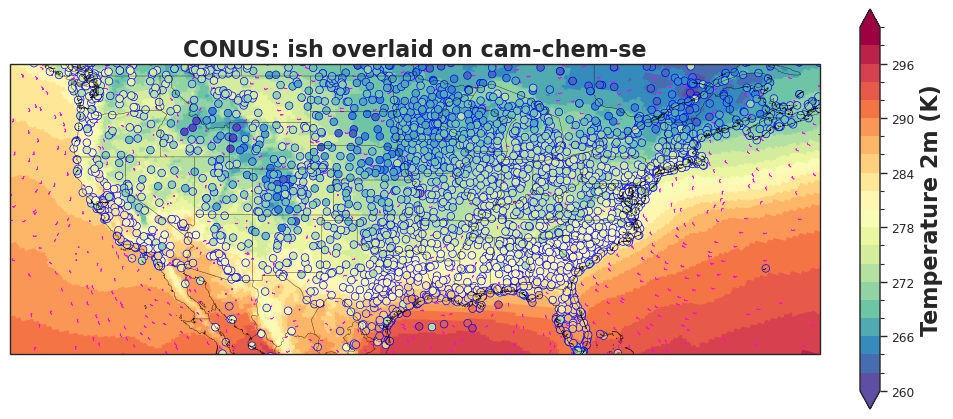

In [ ]:
%%time

an.plotting()

**10 Figures**

::::{card-carousel} 10

:::{card} Figure 1
:img-background: output/camchem/plot_grp1.timeseries.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.png
:width: 50%
:::

:::{card} Figure 2
:img-background: output/camchem/plot_grp1.timeseries.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.png
:width: 50%
:::

:::{card} Figure 3
:img-background: output/camchem/plot_grp2.taylor.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.png
:width: 50%
:::

:::{card} Figure 4
:img-background: output/camchem/plot_grp2.taylor.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.png
:width: 50%
:::

:::{card} Figure 5
:img-background: output/camchem/plot_grp3.spatial_bias.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.airnow_cam-chem.png
:width: 50%
:::

:::{card} Figure 6
:img-background: output/camchem/plot_grp3.spatial_bias.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.airnow_cam-chem.png
:width: 50%
:::

:::{card} Figure 7
:img-background: output/camchem/plot_grp4.spatial_overlay.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.airnow_cam-chem.png
:width: 50%
:::

:::{card} Figure 8
:img-background: output/camchem/plot_grp4.spatial_overlay.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.airnow_cam-chem.png
:width: 50%
:::

:::{card} Figure 9
:img-background: output/camchem/plot_grp5.boxplot.OZONE.2019-09-01_00.2019-09-09_00.all.CONUS.png
:width: 50%
:::

:::{card} Figure 10
:img-background: output/camchem/plot_grp5.boxplot.OZONE.2019-09-01_00.2019-09-09_00.epa_region.R1.png
:width: 50%
:::

::::